In [15]:
import os
import gdown
import shutil
import rasterio
import matplotlib.pyplot as plt
import numpy as np
import random
import cv2


In [2]:
source = "/content/drive/MyDrive/satalite data/data"

destination = "/content/SatelliteDataset"

shutil.copytree(source, destination)



'/content/SatelliteDataset'

In [4]:
for root , dirs , files in os.walk(destination):
  print(f"Root : {root}")
  print(f"No. of Files :{len(files)}")
  print("--------------")

Root : /content/SatelliteDataset
No. of Files :0
--------------
Root : /content/SatelliteDataset/labels
No. of Files :456
--------------
Root : /content/SatelliteDataset/images
No. of Files :306
--------------


In [5]:
with rasterio.open("/content/SatelliteDataset/images/0.tif") as src:
    print("Bands:", src.count)
    print("Shape:", src.height, src.width)
    print("Data type:", src.dtypes)
    print("Dscr:", src.descriptions)
    print("CRS:", src.crs)


    image = src.read()   # shape: (bands, height, width)


Bands: 12
Shape: 128 128
Data type: ('int16', 'int16', 'int16', 'int16', 'int16', 'int16', 'int16', 'int16', 'int16', 'int16', 'int16', 'int16')
Dscr: (None, None, None, None, None, None, None, None, None, None, None, None)
CRS: None


/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


In [ ]:
for i in range(12):
    print(f"Band {i}: min={image[i].min()}, max={image[i].max()}, mean={image[i].mean()}")


Band 0: min=14, max=532, mean=174.0609130859375
Band 1: min=-28, max=846, mean=166.073486328125
Band 2: min=-2, max=1099, mean=326.94390869140625
Band 3: min=2, max=1297, mean=325.7662353515625
Band 4: min=46, max=4975, mean=1945.2276000976562
Band 5: min=30, max=3786, mean=1298.1792602539062
Band 6: min=16, max=3004, mean=678.8449096679688
Band 7: min=64, max=160, mean=66.33984375
Band 8: min=130, max=355, mean=246.9893798828125
Band 9: min=172, max=404, mean=291.104248046875
Band 10: min=10, max=90, mean=20.6011962890625
Band 11: min=0, max=97, mean=4.64495849609375


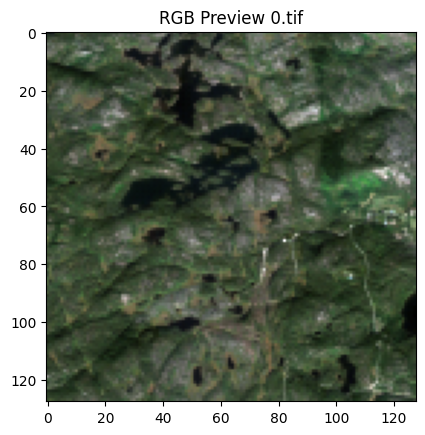

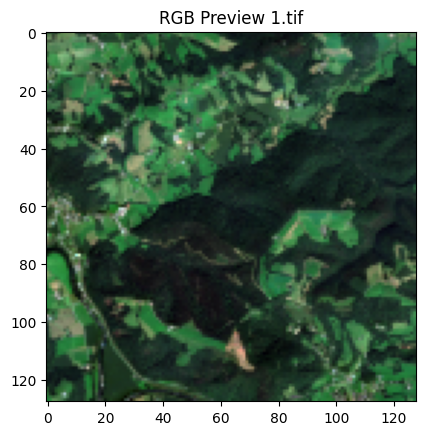

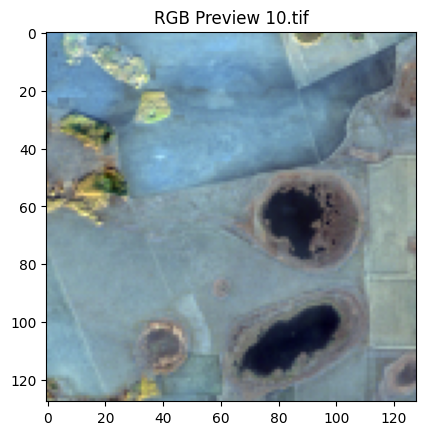

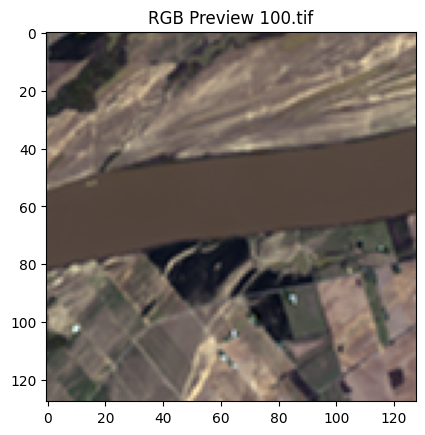

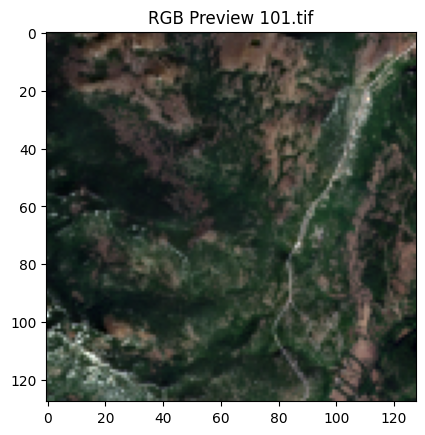

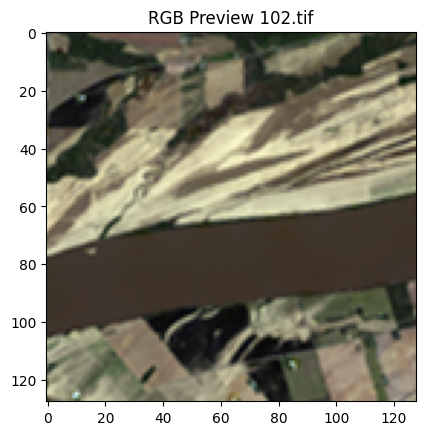

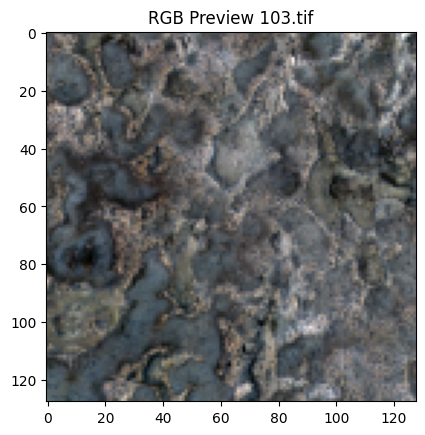

In [6]:
for i , im in enumerate(sorted(os.listdir("/content/SatelliteDataset/images"))):

  path = os.path.join("/content/SatelliteDataset/images" , im)

  with rasterio.open(path) as src:
    image = src.read()

  # Normalize only RGB bands
  rgb = image[[3,2,1]].astype(np.float32)

  for c in range(3):
      band = rgb[c]
      rgb[c] = (band - band.min()) / (band.max() - band.min())

  rgb = np.transpose(rgb, (1, 2, 0))

  #plt.figure(figsize=(5, 5))

  plt.imshow(rgb)
  plt.title(f"RGB Preview {im}")
  plt.show()

  if i == 6:
    break


In [7]:
def preview_satellite_image_grid(image_path):

    with rasterio.open(image_path) as src:
        image = src.read()  # shape: (12, H, W)

    band_names = [
        "Coastal", "Blue", "Green", "Red",
        "NIR", "SWIR1", "SWIR2",
        "QA Band", "Merit DEM", "Copernicus DEM",
        "ESA World Cover", "Water Occurrence Probability"
    ]

    # Prepare figure
    fig, axes = plt.subplots(2, 5, figsize=(25, 10))
    axes = axes.flatten()

    rgb = image[[3,2,1]].astype(np.float32)
    for c in range(3):
        band = rgb[c]
        rgb[c] = (band - band.min()) / (band.max() - band.min())
    rgb = np.transpose(rgb, (1,2,0))

    axes[0].imshow(rgb)
    axes[0].set_title("RGB Composite")
    axes[0].axis("off")

    # Indices to show: 0, 4, 5, 6, 7, 8, 9, 10, 11
    channel_indices = [0, 4, 5, 6, 7, 8, 9, 10, 11]

    for ax_idx, i in enumerate(channel_indices, start=1):
        band = image[i].astype(np.float32)
        name = band_names[i]

        # Choose colormap and normalization
        if i <= 6:  # spectral bands
            band = (band - band.min()) / (band.max() - band.min())
            cmap = "Blues"
        elif i in [8,9]:  # DEMs
            band = (band - band.min()) / (band.max() - band.min())
            cmap = "Blues"
        elif i == 11:  # water probability
            band = band / 100.0
            cmap = "Blues"
        else:  # QA / World Cover
            cmap = "Blues"

        axes[ax_idx].imshow(band, cmap=cmap)
        axes[ax_idx].set_title(name)
        axes[ax_idx].axis("off")

    plt.tight_layout()
    plt.show()


Image : 0.tif


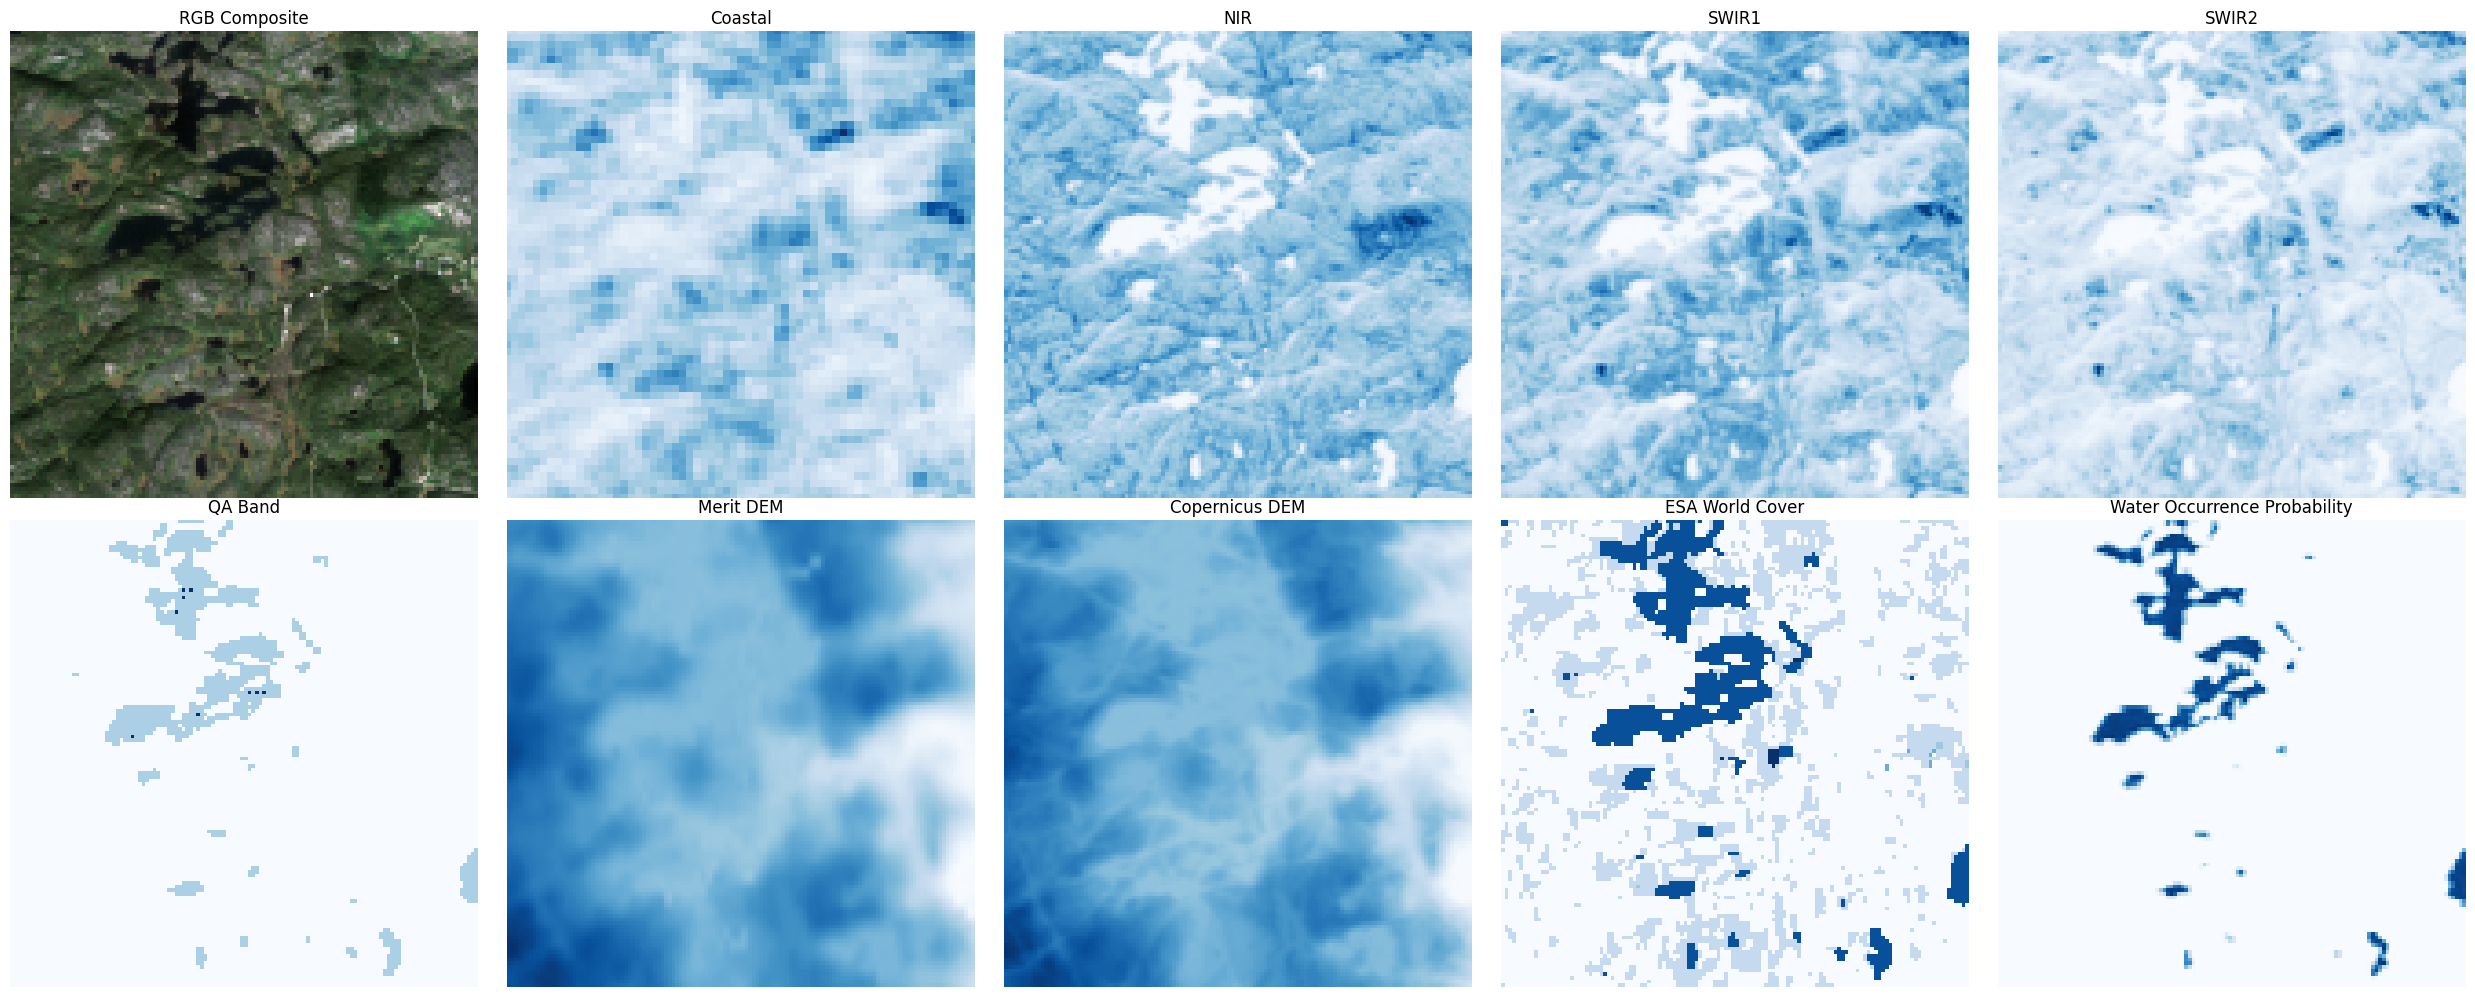



Image : 1.tif


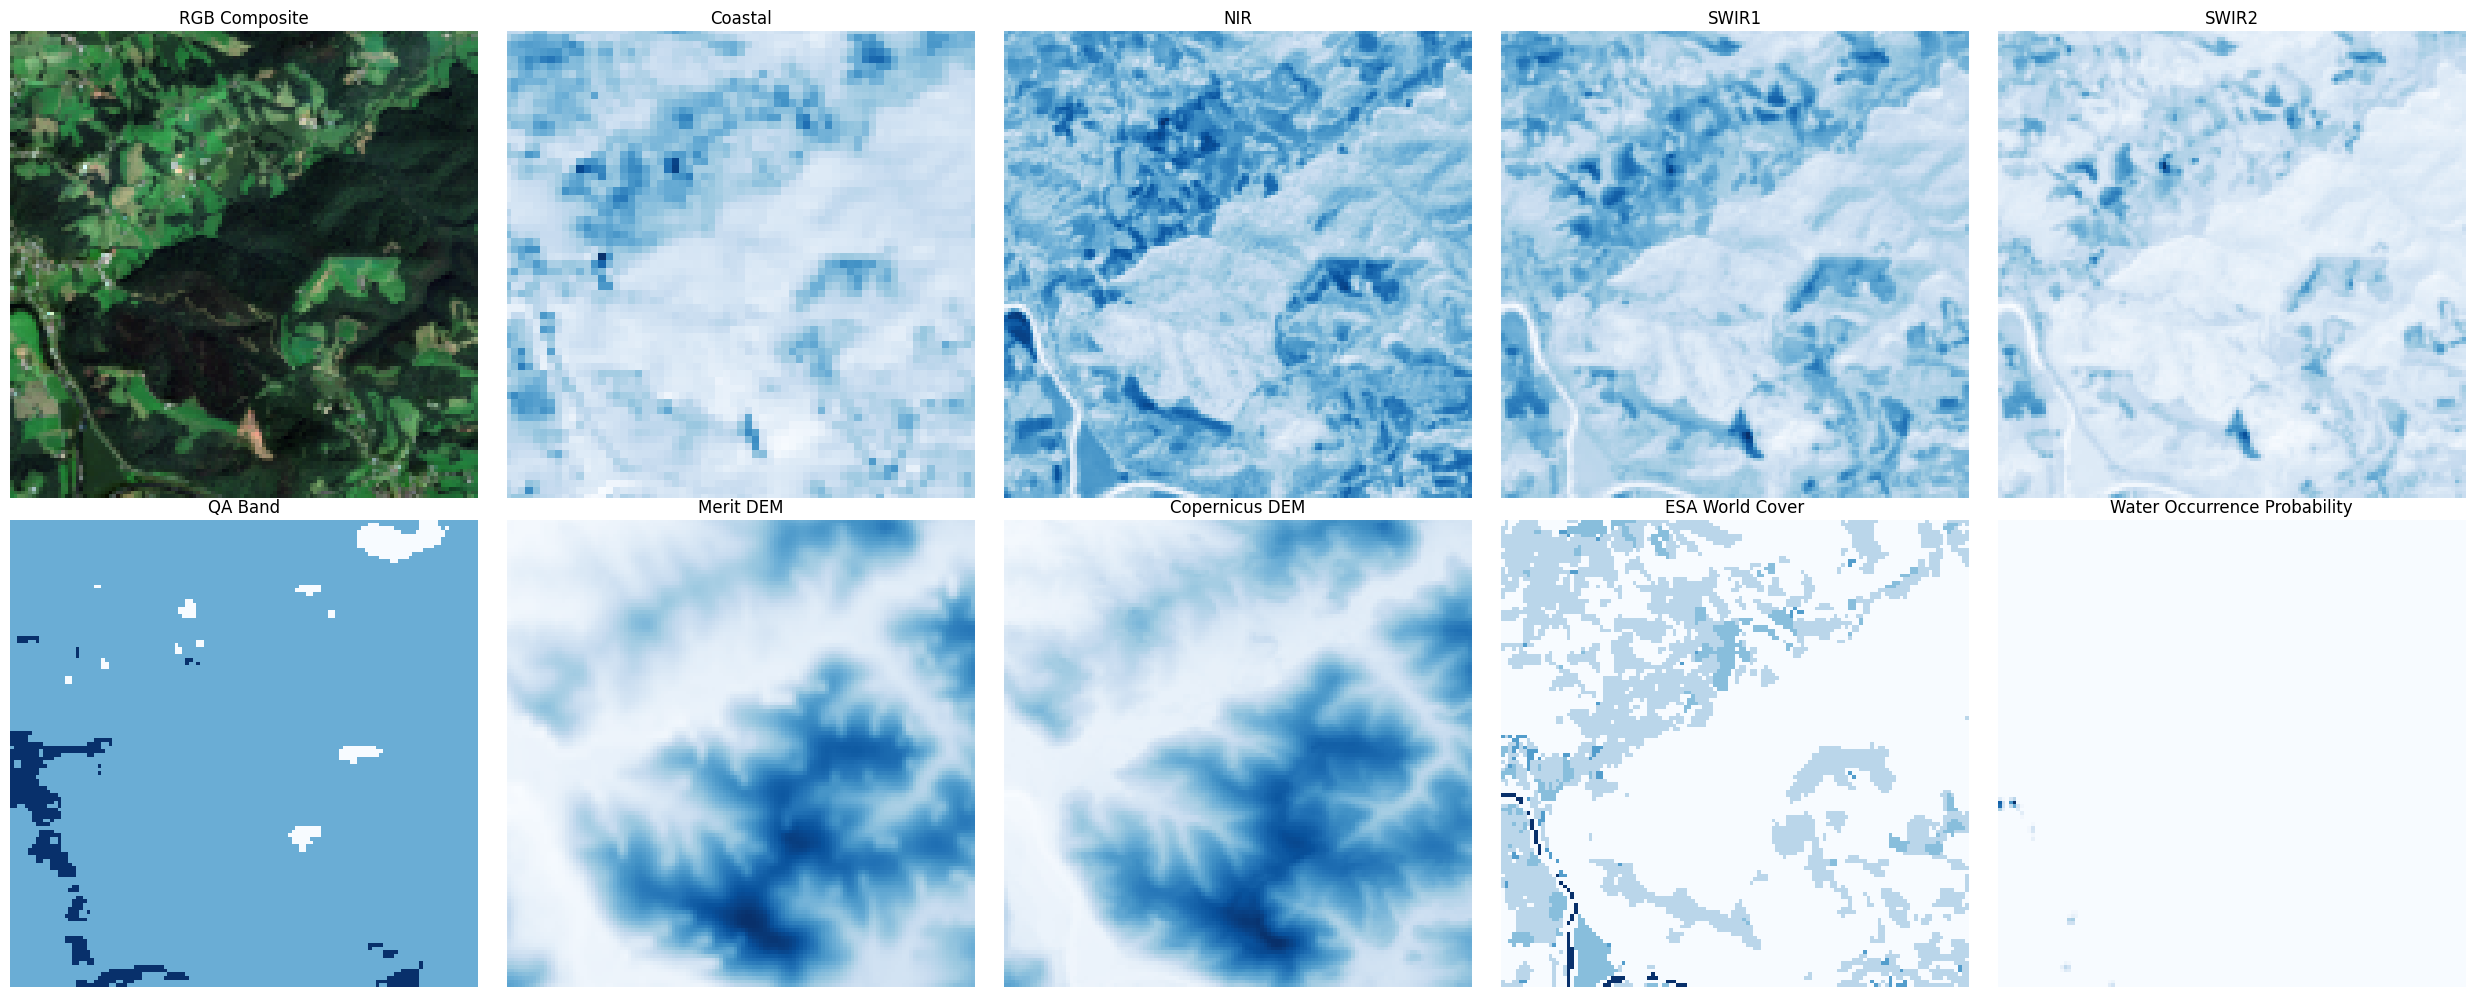



Image : 10.tif


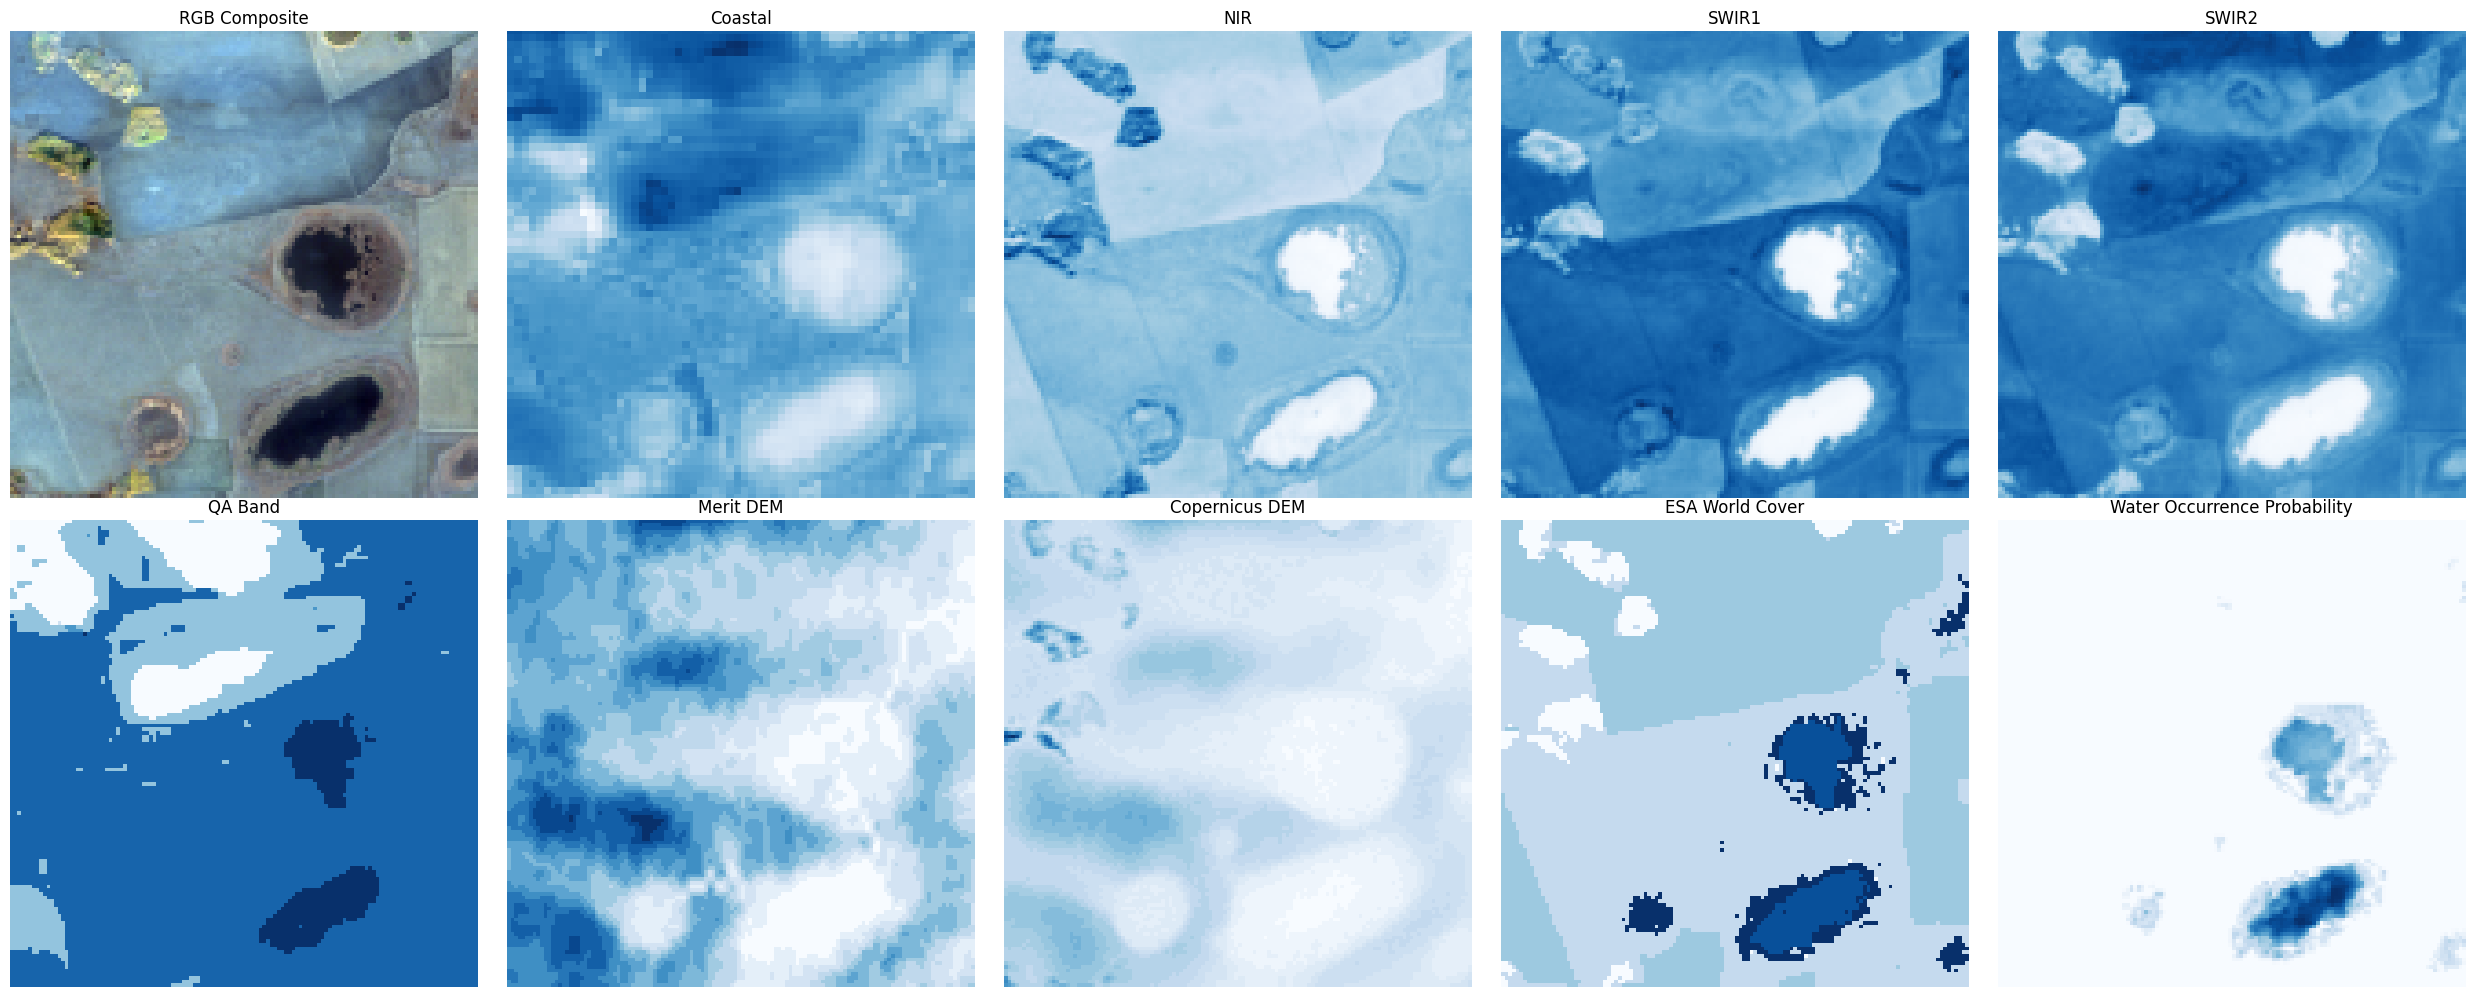



Image : 100.tif


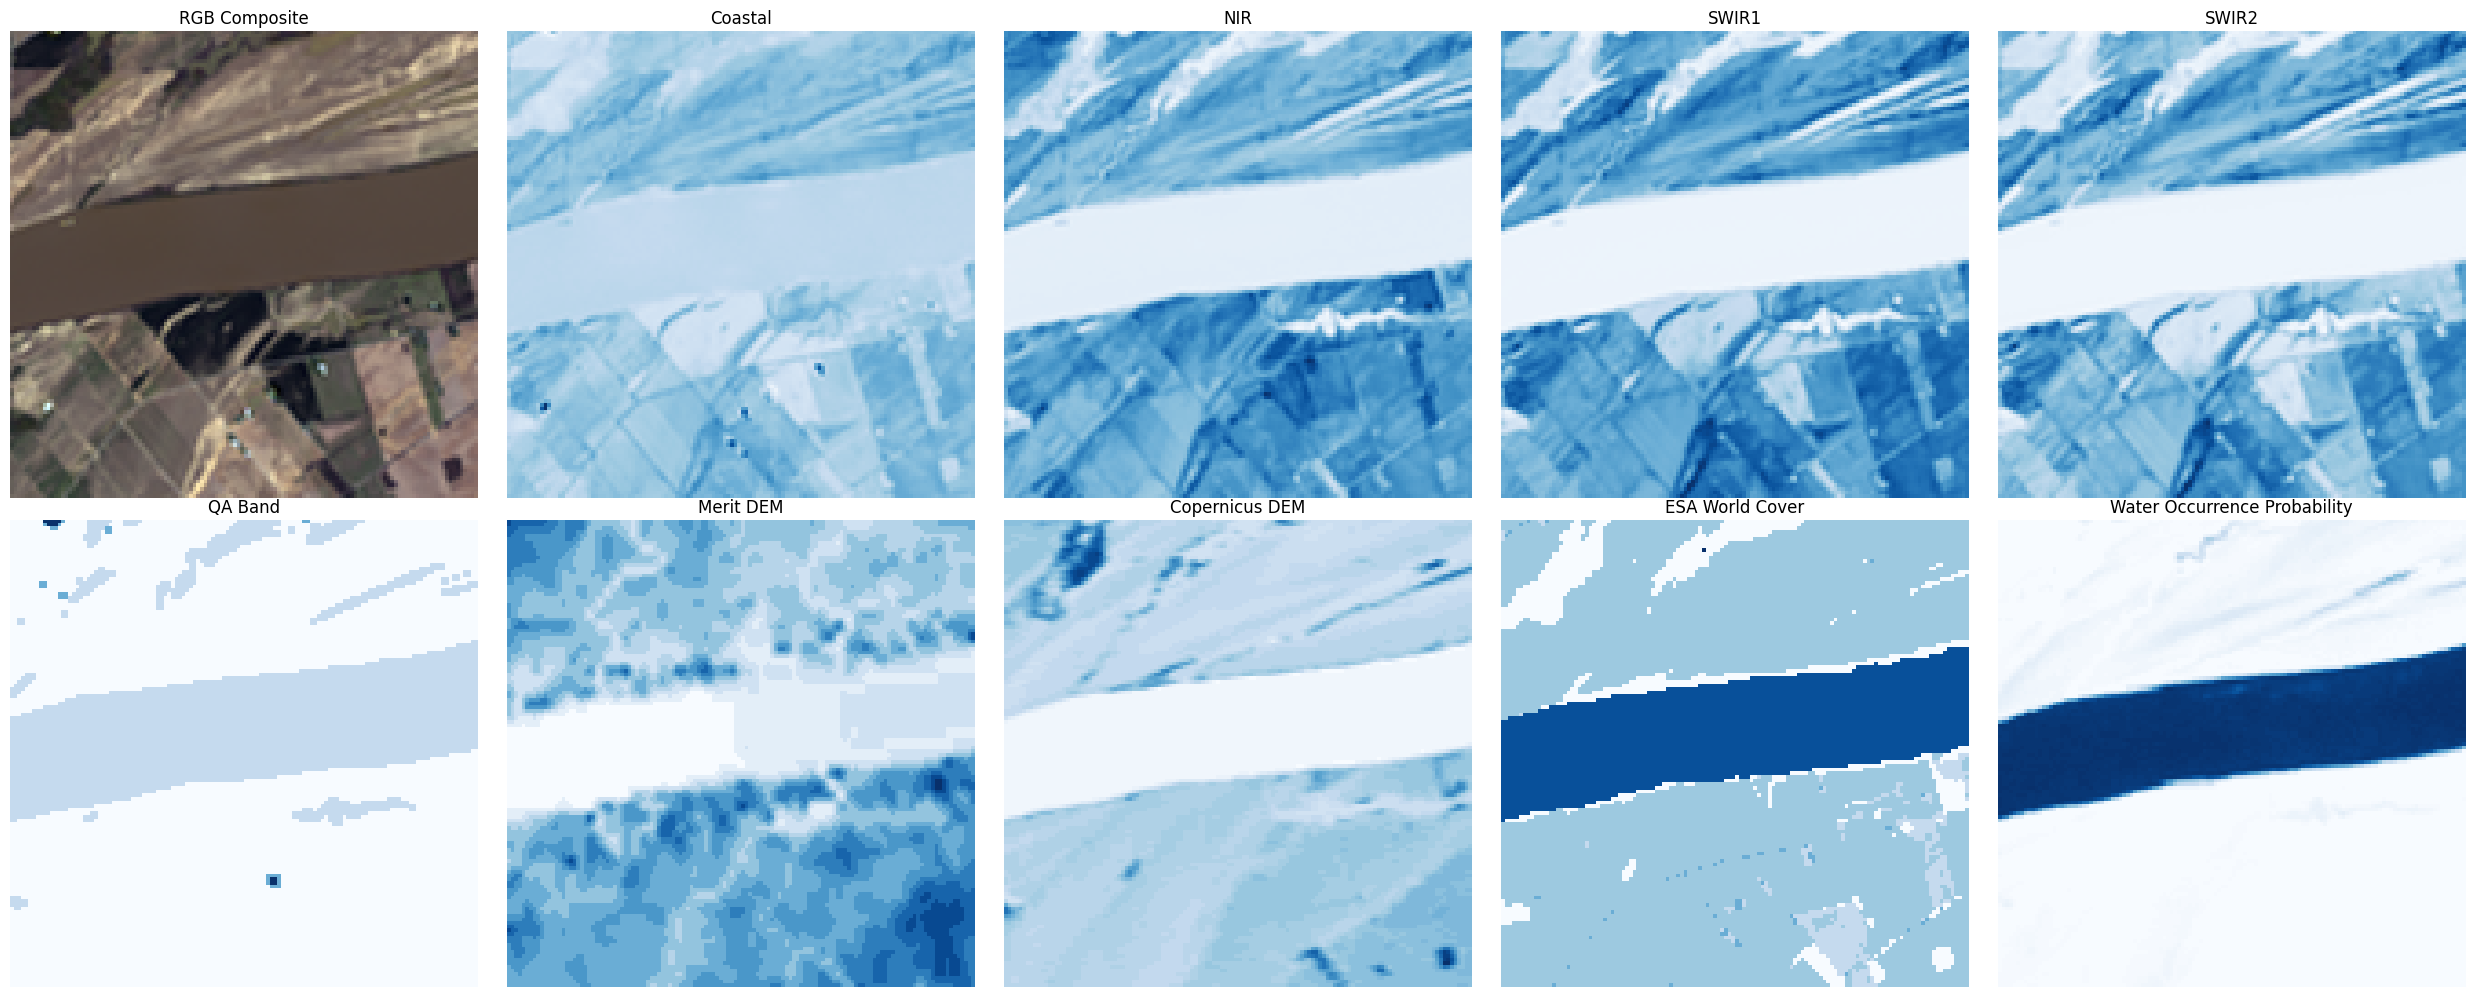



Image : 101.tif


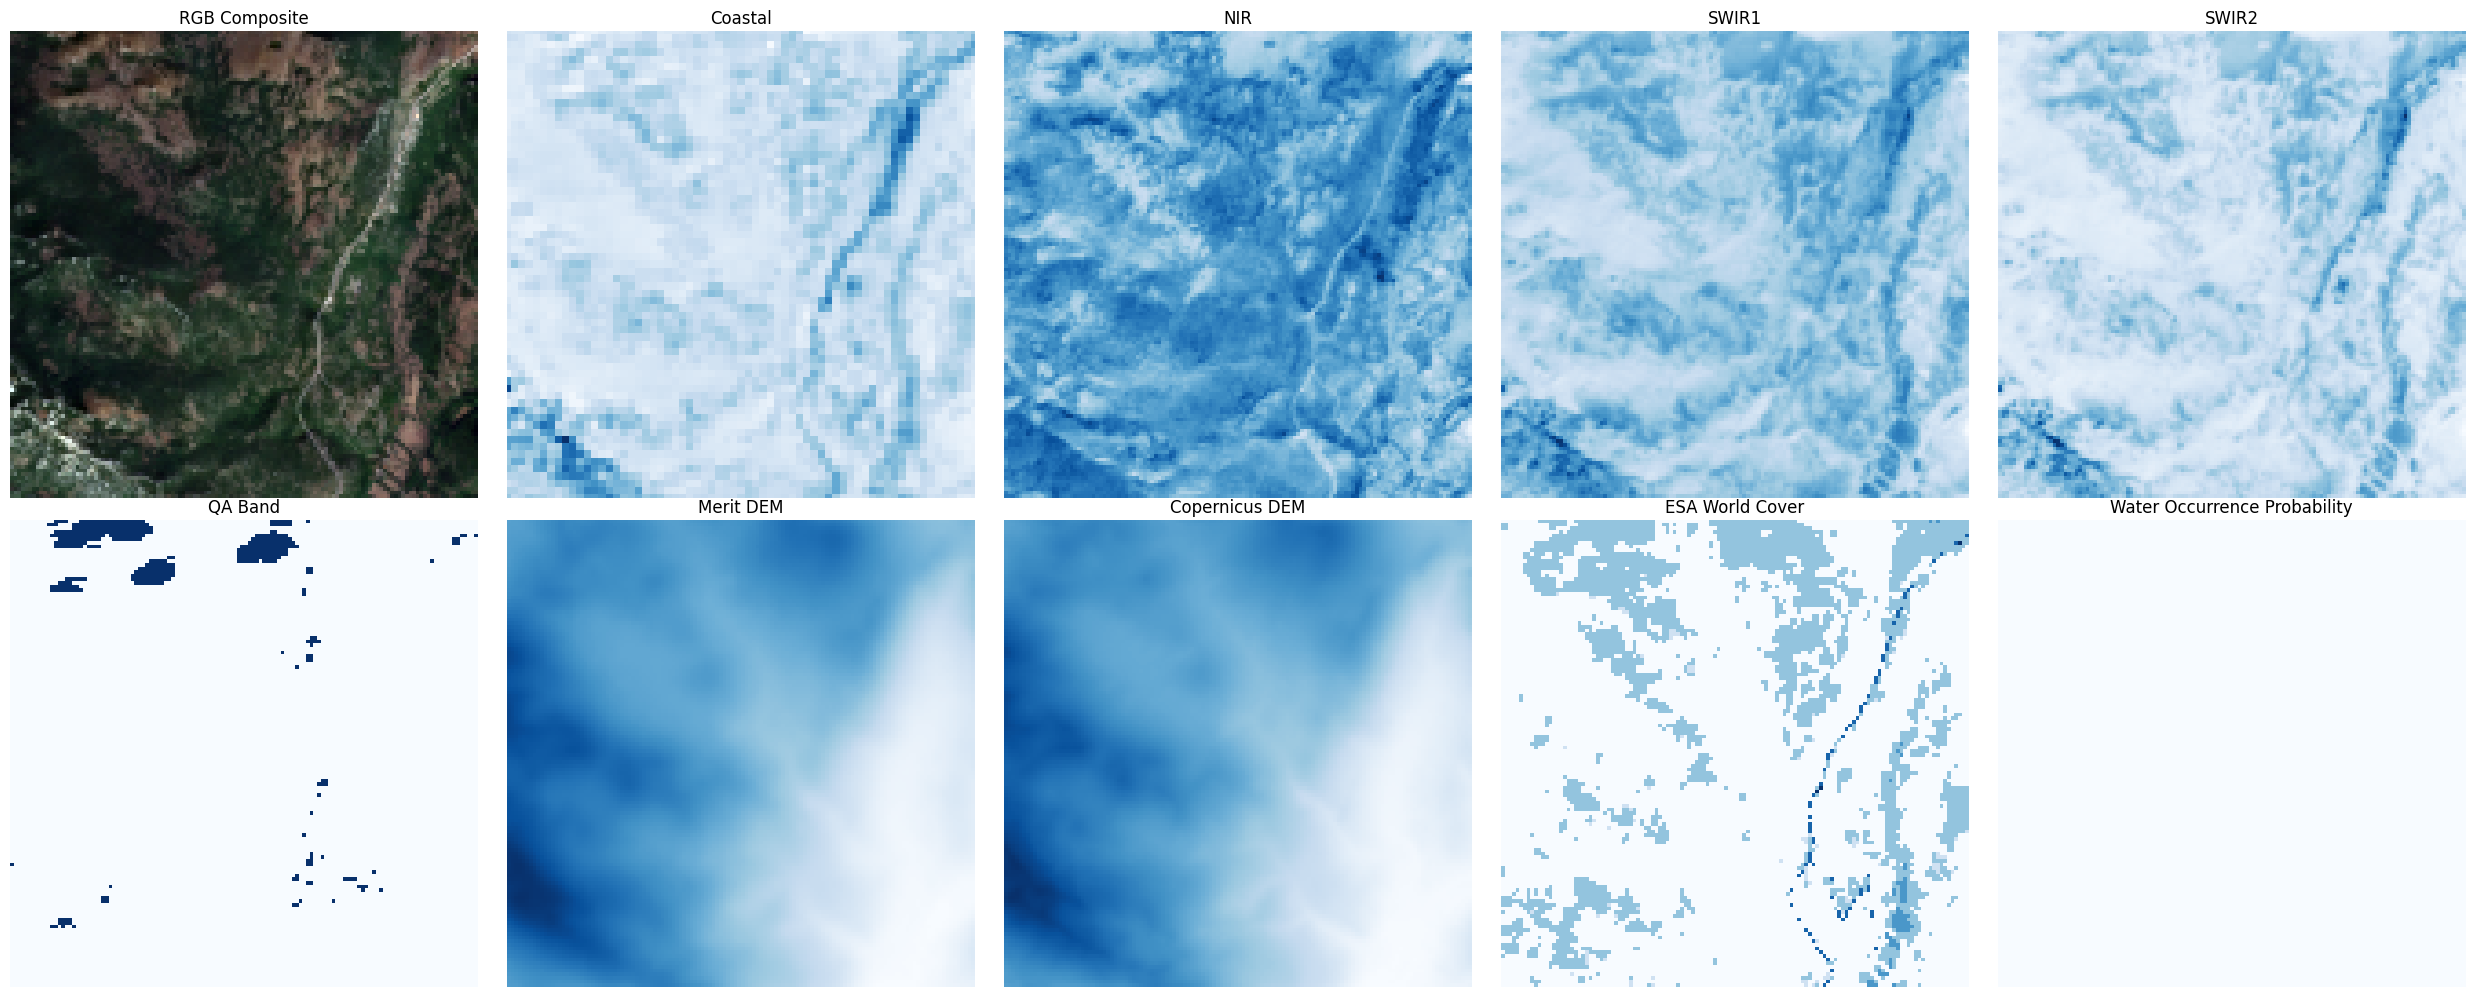



Image : 102.tif


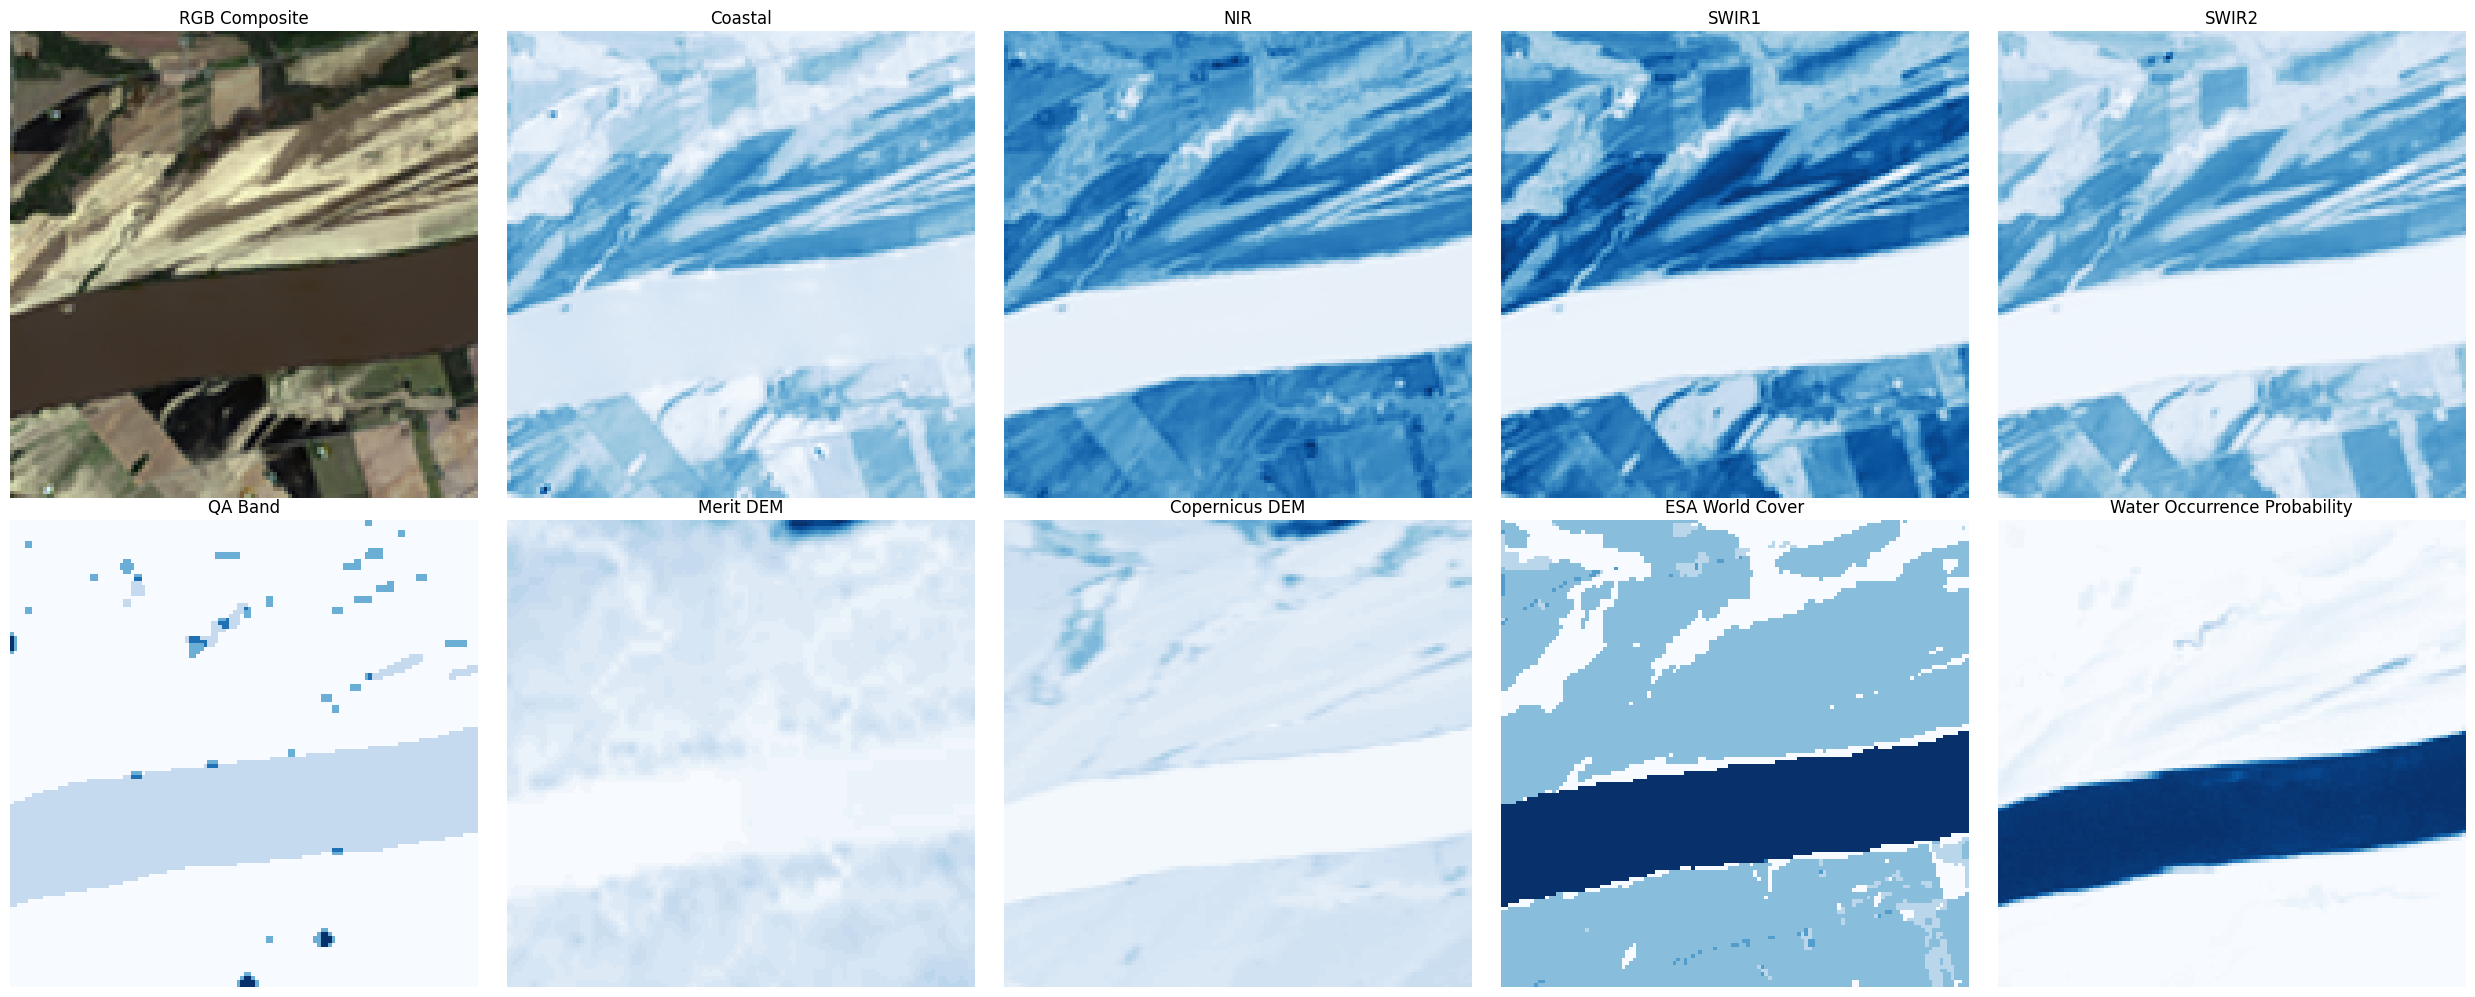

In [8]:
folder = "/content/SatelliteDataset/images"
files = sorted([f for f in os.listdir(folder) if f.endswith(".tif")])

# Preview first 3 images
for f in files[:6]:
  print(f"Image : {f}")
  preview_satellite_image_grid(os.path.join(folder, f))
  print("\n")


In [10]:
input_data = sorted(os.listdir("/content/SatelliteDataset/images"))
labels_data = sorted(os.listdir("/content/SatelliteDataset/labels"))


for i in range(len(max(input_data , labels_data))):

  print(f"Trainging : {input_data[i]} ---- Label : {labels_data[i]}")

Trainging : 0.tif ---- Label : 0.png
Trainging : 1.tif ---- Label : 1.png
Trainging : 10.tif ---- Label : 10.png
Trainging : 100.tif ---- Label : 100.png
Trainging : 101.tif ---- Label : 100_184.png
Trainging : 102.tif ---- Label : 101.png
Trainging : 103.tif ---- Label : 101_89.png
Trainging : 104.tif ---- Label : 102.png
Trainging : 105.tif ---- Label : 102_179.png
Trainging : 106.tif ---- Label : 103.png
Trainging : 107.tif ---- Label : 103_225.png
Trainging : 108.tif ---- Label : 104.png
Trainging : 109.tif ---- Label : 104_20.png
Trainging : 11.tif ---- Label : 105.png
Trainging : 110.tif ---- Label : 105_148.png
Trainging : 111.tif ---- Label : 106.png
Trainging : 112.tif ---- Label : 106_267.png
Trainging : 113.tif ---- Label : 107.png
Trainging : 114.tif ---- Label : 107_59.png
Trainging : 115.tif ---- Label : 108.png
Trainging : 116.tif ---- Label : 108_236.png
Trainging : 117.tif ---- Label : 109.png
Trainging : 118.tif ---- Label : 109_223.png
Trainging : 119.tif ---- Label 

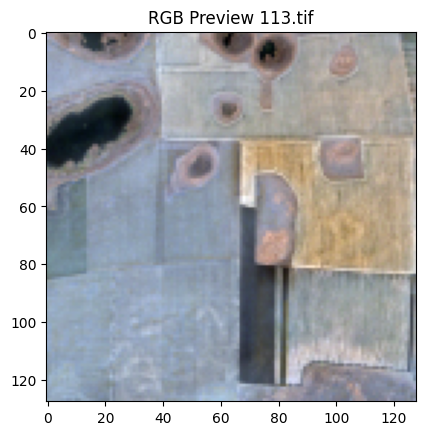

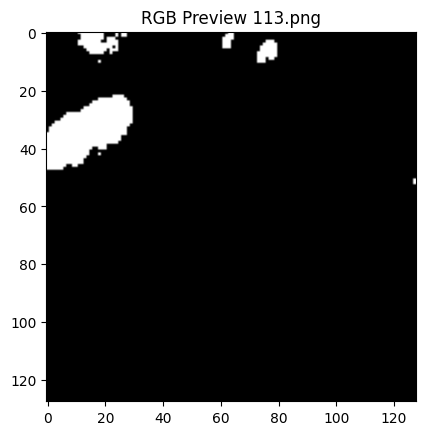

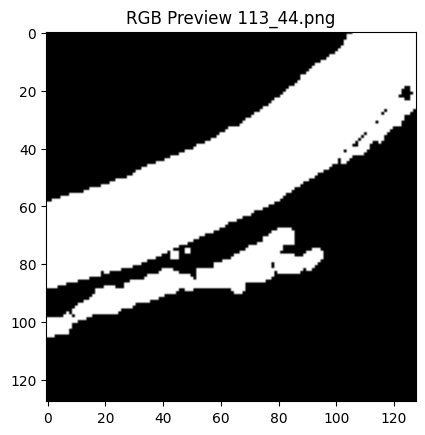

In [ ]:
label_preview = ["113.tif" , "113.png" ,"113_44.png"]



for i in label_preview:
    if i.endswith(".tif"):
        path = os.path.join("/content/SatelliteDataset/images" , i)

        with rasterio.open(path) as src:
            image = src.read()

        # Normalize only RGB bands
        rgb = image[[3,2,1]].astype(np.float32)

        for c in range(3):
            band = rgb[c]
            rgb[c] = (band - band.min()) / (band.max() - band.min())

        rgb = np.transpose(rgb, (1, 2, 0))

        plt.imshow(rgb)
        plt.title(f"RGB Preview {i}")
        plt.show()
    else:
        path = os.path.join("/content/SatelliteDataset/labels" , i)

        # To view binary masks correctly, use gray colormap
        img = cv2.imread(path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = img * 255
        plt.imshow(img, cmap='gray')
        plt.title(f"RGB Preview {i}")
        plt.show()


In [12]:
input_data = sorted(os.listdir("/content/SatelliteDataset/images"))
labels_data = sorted(os.listdir("/content/SatelliteDataset/labels"))

filtered_labels = []

for i in os.listdir("/content/SatelliteDataset/labels"):
  if not("_" in i):
    filtered_labels.append(i)
    print(i)


191.png
10.png
280.png
79.png
243.png
262.png
34.png
6.png
268.png
103.png
249.png
282.png
49.png
204.png
277.png
169.png
234.png
194.png
141.png
207.png
165.png
174.png
8.png
189.png
257.png
184.png
223.png
228.png
95.png
83.png
109.png
302.png
33.png
40.png
232.png
283.png
203.png
295.png
178.png
252.png
205.png
210.png
196.png
38.png
220.png
293.png
64.png
15.png
222.png
105.png
31.png
59.png
143.png
70.png
1.png
91.png
145.png
259.png
102.png
193.png
305.png
7.png
85.png
199.png
86.png
73.png
71.png
153.png
125.png
45.png
287.png
286.png
247.png
246.png
218.png
97.png
274.png
122.png
121.png
281.png
186.png
244.png
76.png
292.png
159.png
303.png
124.png
130.png
195.png
216.png
161.png
229.png
197.png
248.png
285.png
250.png
0.png
29.png
158.png
254.png
74.png
263.png
39.png
273.png
271.png
16.png
114.png
185.png
140.png
35.png
192.png
18.png
99.png
100.png
54.png
225.png
211.png
221.png
172.png
17.png
2.png
267.png
58.png
275.png
233.png
12.png
256.png
237.png
56.png
113.png
167.pn

In [13]:
filtered_labels = sorted(filtered_labels)

for i in range(len(max(input_data , filtered_labels))):

  print(f"Trainging : {input_data[i]} ---- Label : {filtered_labels[i]}")


Trainging : 0.tif ---- Label : 0.png
Trainging : 1.tif ---- Label : 1.png
Trainging : 10.tif ---- Label : 10.png
Trainging : 100.tif ---- Label : 100.png
Trainging : 101.tif ---- Label : 101.png
Trainging : 102.tif ---- Label : 102.png
Trainging : 103.tif ---- Label : 103.png
Trainging : 104.tif ---- Label : 104.png
Trainging : 105.tif ---- Label : 105.png
Trainging : 106.tif ---- Label : 106.png
Trainging : 107.tif ---- Label : 107.png
Trainging : 108.tif ---- Label : 108.png
Trainging : 109.tif ---- Label : 109.png
Trainging : 11.tif ---- Label : 11.png
Trainging : 110.tif ---- Label : 110.png
Trainging : 111.tif ---- Label : 111.png
Trainging : 112.tif ---- Label : 112.png
Trainging : 113.tif ---- Label : 113.png
Trainging : 114.tif ---- Label : 114.png
Trainging : 115.tif ---- Label : 115.png
Trainging : 116.tif ---- Label : 116.png
Trainging : 117.tif ---- Label : 117.png
Trainging : 118.tif ---- Label : 118.png
Trainging : 119.tif ---- Label : 119.png
Trainging : 12.tif ---- Labe

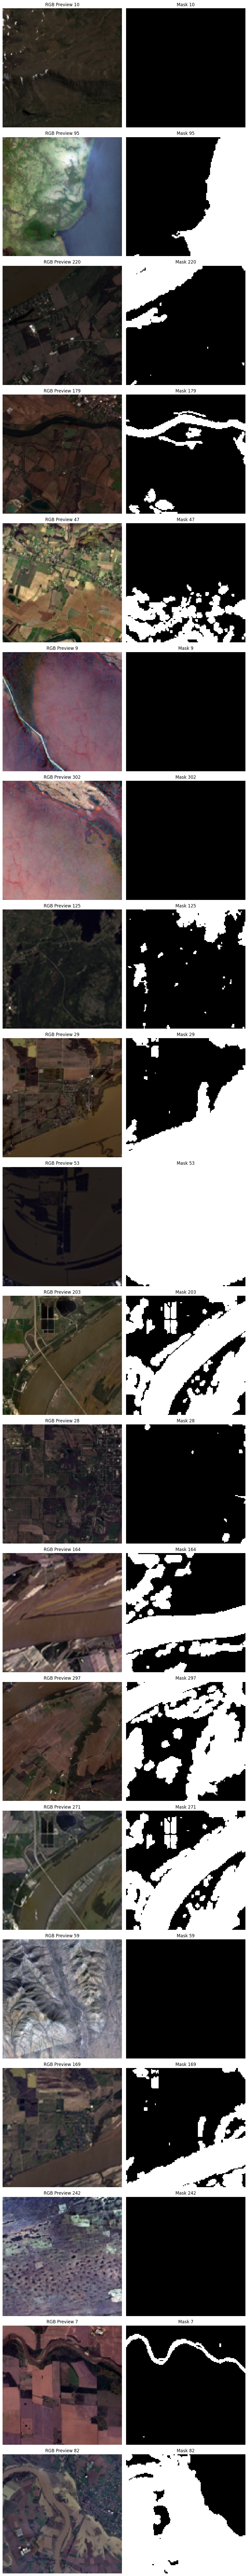

In [16]:
num_samples = 20

# pick random indices
indices = random.sample(range(len(input_data)), num_samples)

fig, axes = plt.subplots(num_samples, 2, figsize=(10, 5 * num_samples), squeeze=False)

for row, idx in enumerate(indices):

    input_tif = input_data[idx]
    input_png = filtered_labels[idx]

    # -------- Image --------
    path_input = os.path.join("/content/SatelliteDataset/images", input_tif)

    with rasterio.open(path_input) as src:
        image = src.read()

    # Normalize RGB bands
    rgb = image[[3,2,1]].astype(np.float32)

    for c in range(3):
        band = rgb[c]
        rgb[c] = (band - band.min()) / (band.max() - band.min())

    rgb = np.transpose(rgb, (1,2,0))

    axes[row][0].imshow(rgb)
    axes[row][0].set_title(f"RGB Preview {idx}")
    axes[row][0].axis("off")

    # -------- Label --------
    path_png = os.path.join("/content/SatelliteDataset/labels", input_png)

    img = cv2.imread(path_png)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = img * 255

    axes[row][1].imshow(img, cmap="gray")
    axes[row][1].set_title(f"Mask {idx}")
    axes[row][1].axis("off")

plt.tight_layout()
plt.show()